In [1]:
from mpl_toolkits.mplot3d import Axes3D
from scipy.io import loadmat
#from sklearn import datasets
import pandas as pd
#import nltk
%matplotlib inline  
%load_ext autoreload
%autoreload 2
from skeleton import *

## Clustering

El proceso de clustering o agrupamiento, es un procedimiento de aprendizaje no supervisado utilizado para descrubir/explorar la estructura de una colección de 
objetos. El objetivo es dividir el conjunto de objetos en grupos/clusters/clases de objetos **similares** mientras son separados de objetos **no similares**. Las clases generadas representan una generalización sobre los objetos y sus características. 

Formalemete, el problema puede definirse como sigue: utilizando como entrada una colección de objetos $X$ y un valor entero $K$ se debe obtener un conjunto $G=\{G_1,G_2,...,G_K\}$. Donde cada objeto  $x_i \in X$ es un vector definido en $\mathbb{R}^N$,  se cumple que  $1 < K \leq |X|$. Al finalizar el proceso cada elemento $x_i$ debe pertenecer a uno de los grupos en $G$

#### Definiciones adicionales
- $m_k$ es el número de elementos en el grupo $G_k$, es decir $m_k=|G_k|$
- $c_k$ será utilizado para referirse al centroide de todos los elementos en $G_k$, el cuál puede ser:
    - la media geométrica $$c_k = \frac{1}{m_k} \sum_{i=1}^{m_k} x_i $$
    - la mediana
    - uno de los elementos en el grupo(centro)
- Se utilizará $M$ para hacer referencia al conjunto de centroides $\{c_1,c_2,...,c_k\}$.
- En el problema de clustering a considerar cada objeto $x_i$ solo pertenece a un grupo, por lo tanto  para cualquier par de grupos  $G_A, G_B$ donde $A \neq B$, se cumple que: 
$$G_A \cap G_B = \emptyset$$.



In [2]:
# Un ejemplo de 3 clusters bien definidos con 100 puntos cada uno
# se utiliza un distribución gaussiana
from sklearn.datasets.samples_generator import make_blobs
blobs_centers = [[-4, 4], [-2, -4], [4, 0]]
blobs_data, blobs_labels = make_blobs(n_samples=300,centers=blobs_centers,random_state=0)
blobs_classes =dict(zip(set(blobs_labels),blobs_centers))

/opt/anaconda3/lib/python3.8/site-packages/sklearn/utils/deprecation.py:143: FutureWarning: The sklearn.datasets.samples_generator module is  deprecated in version 0.22 and will be removed in version 0.24. The corresponding classes / functions should instead be imported from sklearn.datasets. Anything that cannot be imported from sklearn.datasets is now part of the private API.
  warnings.warn(message, FutureWarning)


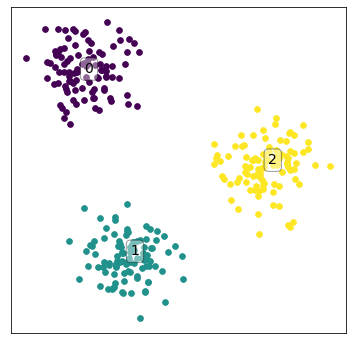

In [3]:
plotClusters(blobs_data,blobs_labels,centroids=blobs_classes)

Como mencionamos el proceso de clustering es una tarea de exploración de datos, lo cual implica que normalmente no se cuenta con información relativa a los resultados esperados del análisis. Algunos de los resultados esperados podrían ser: 

- El número de grupos $K$
- El tamaño de los grupos (número de elementos en cada cluster)
- La densidad de los grupos
- La posición de los clusters

Existen muchas tareas donde se aplica el proceso de clustering, las cuales van desde  aplicaciones de recuperación de información, biología, medicina, negocios, entre otros. Solo por mencionar algunos ejemplos:

Podemos sumarizar el proceso de clustering como sigue:

1. Definición del dominio, lo cual implica: 
    - identificar los objetos a analizar (para nuestro caso sería una colección de tweets)
    - determinar el propósito de generar grupos (generar tópicos, lo describiremos mas adelante)
    - el conjuto de características que describen los objetos (word embeddings)
2. Definir una función de comparación, es decir como se determina que tan parecidos son los objetos
3. Definir como medir la calidad de los gurpos encontrados. 
4. Determinar el algoritmo de clustering a utilizar

### Medidas de distancia/similitud

Una ves definido el dominio del problema es necesario contar un mecanismo para comparar los objetos en la colección. Lo anterior con la finalidad de decir que tan similare o distante es un objeto $x_i$ con respecto de otro $x_j$. Para esto se puede utilizar una función de distancia $d$ o bien una función de similitud $\mathit{sim}$. Distancia y similitud están relacionados, desde que dos objetos que están a una distancia pequeña se puede decir que son similares.  En la siguente tabla se resumen algunas de las funciones de distancia reportadas en la literatura:

|Nombre|Función &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;|
|:--:|:--:|
|Minkowski | $$L_q(x_i,x_j)=\sqrt[q]{\sum_{k=1}^N (x_{ik}-x_{jk})^q}$$| 
|**Coseno** (simulitud)   | $$\cos(x_i,x_j)=\frac{\sum_{k=1}^N x_{ik}*x_{jk}}{\sqrt{\sum_{k=1}^N x_{ik}^2} \sqrt{\sum_{k=1}^N x_{jk}^2}}$$|
**Coseno** (distancia)   | $$dcos(x_i,x_j)=1-\cos(x_i,x_j)$$|
|Divergencia de Kullback-Liebler| $$kld(x_i,x_j)=\sum_{k=1}^N x_{ik}* \log{\frac{x_{ik}}{x_{jk}}}$$|


### Medidas de calidad

Evaluar si un agrupamiento es **"bueno"** o no, no es una tarea simple, desde que no existe un criterio definitivo para determinarlo. Sin embargo se han propuesto muchos criterios de evaluación, los cuales podemos dividir en externos e internos.

#### Medidas internas

Este tipo de medidas evalúan que tan compactos son los clusters mediante el uso de una medida similitud o distancia. Esta clase de métricas generalmente intentan medir la cohesión en cada cluster (intra-cluster), la separación de los diferentes clusters (inter-cluster) o bien una combinación de ambas. Algunos ejemplos son:

##### La suma de los errores al cuadrado (SSE o inercia)

SSE es la medida más simple y consiste en calcular la suma de la distancia de todos los objetos con respecto de los centroides de sus respectivos grupos. Se cálcula mediate la siguente formula:

$$\mathit{SSE} = \sum_{k=1}^{K} \sum_{\forall x_i \in G_k} (x_i-c_k)^2$$

donde $G_k$ es el $k$-ésimo cluster y $c_k$ es el centroide del grupo. SSE es una forma simple de medir que tan diferentes son los elementos en un cluster con respecto de su centro geométrico. Esta medida permite maximizar la similitud entre objetos en el mismo grupo mediante la minimización del SSE. 


##### Silueta

El coeficiente de silueta trata de minimizar la distancia intracluster mientras maximiza la distancia inter-cluster. El coeficiente $\mathit{sil}(G)$  para un conjunto de clusters $G$ se determina como sigue:

1. Para un  elemento  $x_i \in G_A$ su distacia promedio $a_i$ con respecto de todo los elementos en su mismo cluster se cálcula como sigue:

$$a_i=\frac{1}{m_A-1}\sum_{\forall_{x_j} \in G_A} d(x_i,x_j)$$

2. Se cálcula su distancia promedio con mínima $b_i$ con respecto a los elemento que no están en el mismo cluster al que pertenece $x_i$ 

$$b_i=\min_{G_B \neq G_A}\frac{1}{m_B}\sum_{\forall_{x_j} \in G_B} d(x_i,x_j)$$

3. Con el fin de tratar de maximizar la separación entre $x_i$ y los elementos que no están en su mismo grupo, mientras se minimiza la distancia promedio con los que se encuentran en su mismo grupo; se realiza el siguiente cociente: 

$$\mathit{sil}(x_i)=\frac{b_i-a_i}{\max(a_i,b_i)}$$

4. Se suma el coeficiente para todos los elementos en un mismo clusters

$$\mathit{sil}(G_k)= \frac{1}{m_k} \sum_{x_i} \mathit{sil}(x_i)$$

5. Finalmente se suman los coeficientes de cada grupo para obtener el coeficiente global

$$\mathit{sil}(G)= \frac{1}{K} \sum_{k=1}^K \mathit{sil}({G_k})$$

Está métrica tiene un costo mucho mayor que el SSE ya que en el peor caso se requiere conocer la distancia entre todos los elementos de la colección lo cual no es factible para coleccion muy grandes.

#### Medidas externas

Las medidas externas requeiren que se conozcan a priori el número de grupos, así como la pertenencia de los elemetos a cada uno de ellos. Algunas de la medidas que pueden utilizarse son $\mathit{precision}$, $\mathit{recall}$ y $F_1$. Si recodamos: 

$$\mathit{recall}=\frac{tp}{tp+fn}$$

$$\mathit{precision}=\frac{tp}{tp+fp}$$

$$F_1=2 \frac{precision \cdot recall}{precision + recall}$$


donde $tp$ son los verdaderos positivos y $fn$ los falsos negativos, en el contexto de clustering lado un grupo $G_k$ los $tp$ serían los elemnetos que fueron asignados a $G_k$ y sí pertenecen a $G_k$. Por otro lado los $fn$ serían los elementos que fueron asignados $G_k$ sin pertenecer a él. Los falsos positivo $fp$ son los elementos que fueron asignados a un cluster diferente a $G_k$.

#### Como elegir el valor de $K$?

Este problema ha sido objeto de muchos estudios, pero solo mencionaremos brevemente dos métodos de los muchos que existen en la literatura. 
- **Método de Elbow**: Consiste en calcular el valor del $SSE$ para valores continuos de $K$ y elegir el valor en que se da el cambio máximo en el valor de $SSE$.

- **Método de la silueta**: En este caso de cálcula el valor del coeficiente de silueta y se elige el valor de $K$ que presente el valor máximo del score. 

En la siguente gráfica se muestra el valor de ambos criterios para la base  de digitos, la cual es parte de **sklearn.datasets**. Como puede verse para este caso utilizando el criterio de Elbow el valor óptimo sería $K=4$; mientras que si utilizamos Silueta esto sería $K=9$.

|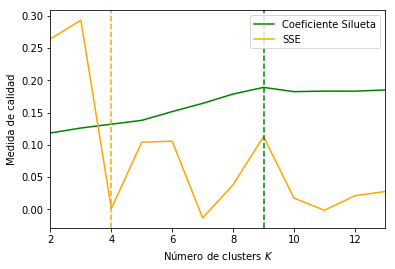|
|:----:|
|**Ejemplos de criterios de selección del valor de K para la DB de digitos**|

Para este caso partícular la silueta identifica el valor correcto, pero la realidad es que no existe un método que del el valor correcto para cualquier conjunto de datos. Por ejemplo vea que método parece haber eligido el valor correcto para el siguiente dataset, que contiene los datos para tres tipos de flores de Iris...

|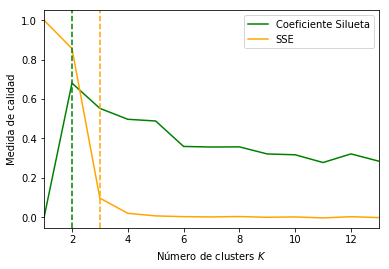|
|:----:|
|**Ejemplos de criterios de selección del valor de K para la DB Iris**|

### Algoritmos de Clustering
Los diferentes algoritmos de clustrering pueden ser divididos con respecto a como crean los grupos, esto es en si lo hacen de forma jerárquica o particional. Un algoritmo particional crea el conjunto de clusters dividiendo los objetos en grupos disjuntos, lo cual se puede realizar hasta obtener grupos con un único elmento. Mientras que los métodos jerárquicos permiten la existencia de sub-grupos, es decir grupos anidados. El proceso de clustering puede verse como un árbol binario (dendrograma) en el que las hojas son los clusters que contienen un solo elemento, los nodos internos representan la unión de sus dos hijo y la raíz sería un único cluster que contiene todos los objetos en la colección.

|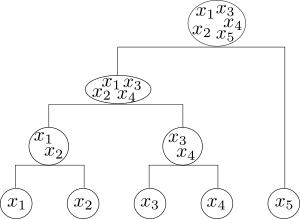|
|:--:|
|**Dendrograma (Clustering Jerárquico)**|

Nosotros nos enfocaremos en métodos particionales.

#### $K$-Means

Es un algoritmo basado en particionado. El algoritmo requiere como entrada la colección $X$ y el número de clusters $K$. El proceso comienza seleccionando $K$ elementos de $X$, los cuales son utilizados como los centroides iniciales. Posteriormente cada punto es asignado a su centroide más cercano, todos los elementos asignados a un mismo centroide forman un cluster. Una vez asignados todos lo elementos se cálcula el centroide $c_k$ para cada uno de los grupos. Se repiten el proceso de asignación y actualización de los centroides hasta que no hay cambios en los centroides. Podemos resumir el algoritmo en el siguiente listado:



------
**Algoritmo básico para K-Means**


------
1. Seleccionar $K$ objetos de $X$ como centroides iniciales
2. **repetir**
3. &nbsp;&nbsp;&nbsp;&nbsp;Para cada $x_i \in X$ asignar $x_i$ al grupo representado por su centroide más cercano 
4. &nbsp;&nbsp;&nbsp;&nbsp;Recálcular los centroides en base a los grupos obtenidos
5. **hasta** que los centroides no cambien
------
------


Para el paso 3 se utiliza alguna función comparación, ya sea de distancia o similitud. En esta punto algunas de las consideraciones que hay que tomar para asegurar convergencia del método $K$-Means se resumen en la siguiente tabla:

   
|Función de comparación| valor para el centroide | Función objetivo &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;|
|:---:|:---:|:---:|
|Distancia Euclidiana| media|  $$\min \sum_{k=1}^{K}  \sum_{\forall x_i \in G_k} (x_i-c_k)^2$$|
|Distancia Manhattan | mediana|  $$\min \sum_{k=1}^{K} \sum_{\forall x_i \in G_k} |x_i-c_k|$$|
|Similitud Coseno    | media|  $$\max \sum_{k=1}^{K} \sum_{\forall x_i \in G_k} \cos(x_i-c_k)$$|

La siguiente figura muestra el proceso de convergencia del $K$-Means para un conjunto de 90 elementos y $K=3$ clusters:

|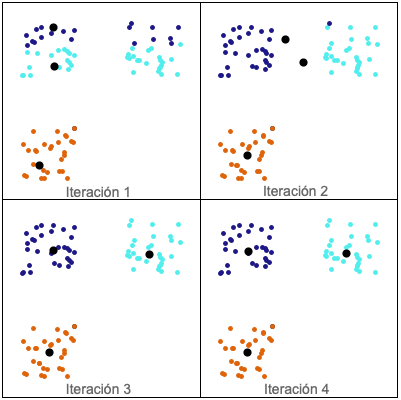|
|:--:|
|**Iteraciones $K$-Means**|



#### $K$-Centros y Farthest First Traversal

El problema de los $K$-Centros consiste en dado un número limitado de facilidades ($K$) encontrar la forma de ubicarlas de tal forma los usuarios más alejados tengan un coste mínimo para acceder a dichas facilidades. Como ejemplo suponga que hay $n$ personas en edad escolar, de las cuales conoce la ubicación de su vivienda. Se pretende construir $K$ escuelas, pero eligiendo las posiciones de tal forma  que la distancia $r$ que los niños más alejados tengan que recorrer para acudir a clase sea mínima. En este las distintas ubicaciones pueden verse como un conjuto de puntos en un espacio bidimensional. Para solucionar el problema deben elegirse las posiciones en las que debe construirse cada escuela minimizando la distancia máxima $r$.  

Si consideramos que los puntos que generamos previamente en los blobs corresponden a las posiciones de los habitantes y se quieren construir 3 escuelas; entonces una solución simple es ubicarlas en la posición correspondiente al centroide de cada nube de puntos:

|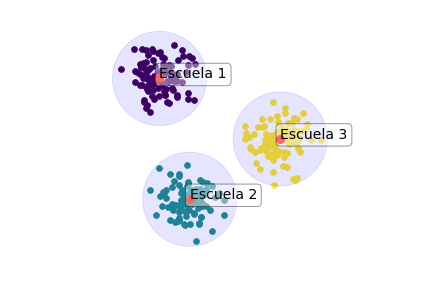|
|:---:|
|**Solución ideal para los $K$-centros cuando los datos siguen una distribución gaussiana**|

desafortunadamente no todos los datos provienen de distribuciones normales con media cero y varianza unitaria. Por ejemplo no es tan obvio utilizar la misma idea para los siguientes datos:

|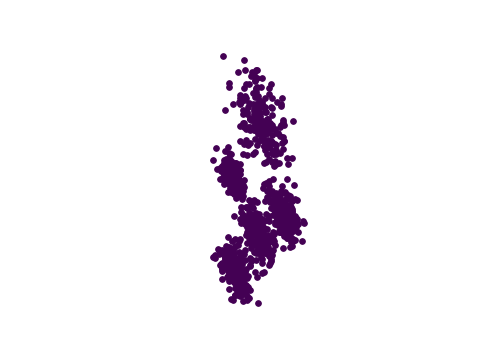|
|:---:|

La solución no es obvia, pero podría utilizarse $K$Means para encontrar tres clusters y construir la esculeas en los centroides.


|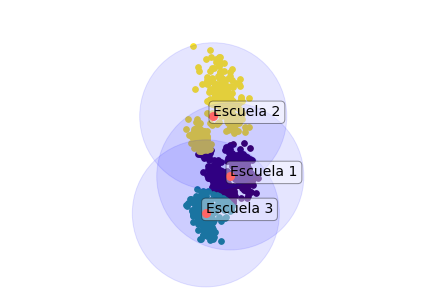|
|:----:|
|**Utilizando $K$Means para 100 ejecuciones se obtiene en promedio una distancia máxima de $r=37$ y un $SSE=128141.13$**|

$K$Means tiende a favorecer  la zona más densa (ahí quedaron 2 escuelas). Lo cual podría ser bueno, ya quiere decir que la mayoría de los estudiantes tienen que desplazarse poco, pero es muy probable que para este caso la distancia máxima no sea mínima.

¿Para un caso como este se podría tener una mejor solución? La respuesta es sí, mediante el uso de Farthest First Traversal FFT.

|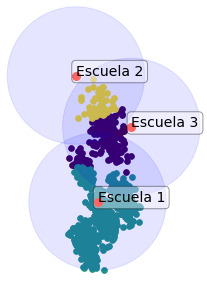|
|:----:|
|**Utilizando FFT para 100 ejecuciones se obtiene en promedio una distancia máxima de $r=33.38$ y un $SSE=24198.58$**|

**Farthest First Traversal (FFT)**

FFT es un algoritmo que permite seleccionar $K$ centros de una colección de objetos. Un centro a diferencia de un centroide es un elemento que forma parte de la colección de datos. En FFT cada centro es seleccionado de tal forma que cualquier objeto $x_i \in X$ está a lo más  una distancia $r$ de uno de los centros. Al igual que $K$Means, FFT es un algoritmo de pariticionado, solo que en este caso cada $G_k \in G$ será defino en base a  la partición generada por los centros, utilizaremos $R_C$ para referiremos al conjunto de centros generados por el algoritmo.

Este algoritmo fue inicialmente propueste por Teofilo Gónzalez como un aproximación a la solución del problema de $K$-Centros, la cual es a lo más dos veces la solución óptima. Utilizando FFT podemos calcular un conjunto $R_C$, conde cada $c_j \in R_C$ son lejanos entre si. Esto se consigue simulando un recorrido, donde en cada iteración $k$, $c_k$ es seleccionado como el elemento más alejado de los elementos ya seleccionados. Sea  $r_k$ la distancia utilizada para seleccionar el centro $c_k$, entonces en la iteración $k$ se cumple que:

- Cualquier par de objetos $x_i,x_j \in X$ se encuentran al menos a distancia $r_k$ el uno del otro.
- Cualquier elemento $x_i \in X$ se ecuentra a lo más a distancia $r_k$ de uno de los centros $c_j \in R_C$ (cada elemento se asigna a la partición de su centro más cercano)

Para facilitar la definición del algoritmo definimos $d_{\min}(x)$ como la distacia entre un elemento $x$ y su centro más cercano en $R_C$, entonces: 
$$d_{\min}(x)=\min\{d(x,c) \mid c \in R_C\}$$

------
**Algoritmo Farthest First Traversal**


------
1. $c_1 \gets x_i$, donde $x_i$ es seleccionado aleatoriamente de $X$
2. $R_C \gets \{c_1\}$ 
3. **Mientras** $|R_C|<K$
4. &nbsp;&nbsp;&nbsp;&nbsp; $c_n \gets \arg\max\{d_{\min}(x) \mid x \in X \setminus R_C\}$ 
5. &nbsp;&nbsp;&nbsp;&nbsp; $r \gets \max\{d_{\min}(x) \mid x \in X \setminus R_C\}$
6. &nbsp;&nbsp;&nbsp;&nbsp; $R_C \gets R_C \cup \{w\}$
7. $G \gets \{G_1,G_2,...G_k\}$ 
------
------

donde cada $G_k$ es el conjuto de los elemento $x_i$ que tiene como su centro más cercano al centro $c_k$

La siguiente figura muestra la evolución de algoritmo FFT, puede observarse que la distancia máxima disminuye a cada iteración; asi como el orden en que se eligen los puntos.

|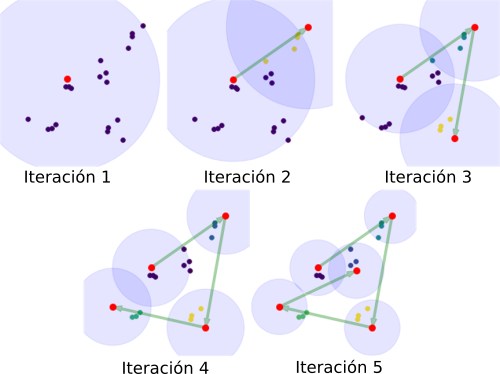|
|:----:|
|**FFT para $K=5$ sobre 5 nubes de puntos generadas mediante una distribución normal**|

FFT tiene la ventaja adicional que su complejidad está acotada por $O(D K n)$ donde $D$ es la dimensión de los datos, $n$ el número de elementos en la base de datos y $K$ el número de centros. La solución mencionada es la mejor solución conocida para el problema. Por otro lado la solución obtenida es a lo más 2 veces la solución ópitma. Si utilizamos $K$Means la solución es $O(K D n I)$ donde I es el número de iteraciones.  Finalmente hay que notar que los dos algoritmos optimizan variables difierentes, mientras que $FFT$ minimiza la distancia máxima de los datos a uno de los centros; $K$ means optimiza el error cuadrático $SSE$.  

## Identificación de tópicos

La identificación de tópicos consiste en obtener los *temas* de los que se habla en una colección de documentos. Una forma natural de resolver este problema es agrupando los documentos similares y aplicar un análisis estadístico para identificar los términos o conjunto de términos que representan un tópico. Note que un tema o tópico no sólo se requiere obtener las palabaras que más repiten, sino que esas palabras tengan un significado juntas (recuerde como se aprenden los embeddings!). Algunas apliciones relacionadas con identificación de tópicos son:  La sumarización de documentos, encontrar los tópicos relevantes en grandes colecciónes de documentos, por ejemplo resumir los eventos relevantes que ocurrieror en la bolsa, o durante un día de campaña; clasificación de documentos no supervisada utilizando los tópicos generar las categorías, análisis de sentimiento, etc....

En nuestro caso de estudio queremos generar los tópicos para el conjunto de tweets de la campaña presidencial de 2018. El poceso de identificación que propondremos será el descrito por la siguiente figura.

|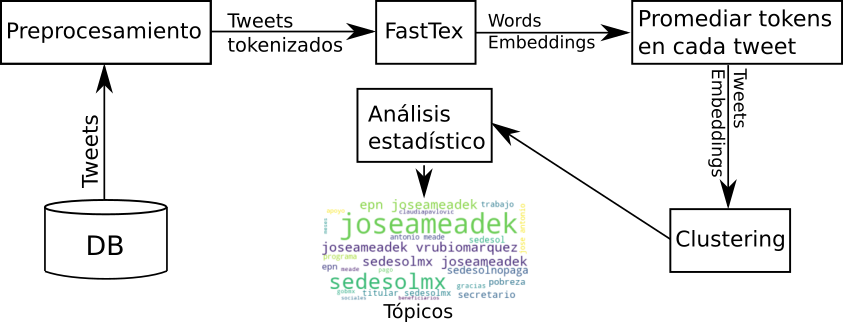|
|:---:|
|**Pipeline para la identificación de tópicos**|

In [4]:
# ! pip install wordcloud #instalamos wordcloud si no se tiene aún
# ! conda install wordcloud

A continuación un breve ejemplo del pipeline

### Cargamos la base datos

In [5]:
# Ilustraremos el ejemplo con 10000 tweets solamente
sample_tweets=pd.read_csv('dominio-elecciones18.csv').text[:10000]

FileNotFoundError: [Errno 2] No such file or directory: 'dominio-elecciones18.csv'

### Aplicamos preprocesamiento

In [ ]:
#tokenizamos
sample_tokens=tokenize_sentences(sample_tweets)
print("Ejemplo de tweet tokenizado: ",sample_tokens[900])

In [ ]:
#Para toda la db
#all_tweets=pd.read_csv('dominio-elecciones18.csv').text
#all_tokens=tokenize_sentences(all_tweets)

### Obtenemos un modelo FastTex  para generar los word embeddings

In [ ]:
# definimos el modelo 
sample_model = FastText(size=100, window=3, min_count=1, min_n=2, max_n=5)

In [ ]:
#construimos el vocabulario
sample_model.build_vocab(sentences=sample_tokens)

In [ ]:
# Entremanos el modelo
sample_model.train(sentences=sample_tokens,total_examples=len(sample_tokens), epochs=10)

### Generamos los tweets embeddings 

In [ ]:
tweets_embeddings=np.array([np.mean([sample_model.wv[token] for token in tweet],axis=0) 
                   for tweet in sample_tokens])

In [ ]:
# obtenemos 10000 tweets embedings de dimension 100
tweets_embeddings.shape # todo listo para el clutering!

In [ ]:
#Podríamos utilizar el modelo para generar los embedings para toda la DB
#all_embeddings=np.array([np.mean([sample_model.wv[token] for token in tweet],axis=0) 
#                   for tweet in all_tokens])

In [ ]:
#hacemos aliases para escribir menos
te=tweets_embeddings
tk=tokens

### Aplicamos clustering utilizando los tweet embedings

In [ ]:
# El método randomClustering es equivalente a la primera iteración de KMeans,
# solo seleccionamos k elementos y asignamos toda la colección a su elemento más
# cercano 
cluster_model=Clustering(n_clusters=5,algorithm="randomClustering",distance_function=coseno).fit(te)

Podemos ver los clusters en dos dimensiones

In [ ]:
plotPCA(te,cluster_model.labels_,centroids=cluster_model.centroids_,d=2,vectors=False)

In [ ]:
# Solo los centroides
# hacemos que los vectores de los centroide sean los datos
# y sus etiquetas el parámetro labels
labels,vals=list(zip(*cluster_model.centroids_.items())) 
plotPCA(np.array(vals),labels,centroids=cluster_model.centroids_,d=2,vectors=True)

In [ ]:
# Utilizaremos wordcloud para hacer una estadistica visual
from wordcloud import WordCloud

In [ ]:
#mostramos las nubes de palabras
i=1
fig=plt.figure(figsize = (10, 8), facecolor = None)
for k,v in cluster_model.centroids_.items():
    ftext=' '.join([' '.join(token) for token in tk[np.where(cluster_model.labels_==k)]])
    print("Cluster id:%s, Numero de elementos: %s " 
          %(k,tk[np.where(cluster_model.labels_==k)].shape[0]))
    wordcloud = WordCloud( background_color ='white', min_font_size = 10).generate(ftext) 
    ax=fig.add_subplot(3,2, i)
    plt.imshow(wordcloud,interpolation="bilinear")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect(1.0)
    i=i+1
plt.subplots_adjust(hspace=0.1,wspace=0)
plt.show()
    

## Actividad

Generar una lista de tópicos sobre los tweets de las elecciones presidenciales de 2018. Para la tarea el estudiante deberá implementar dos  algoritmos de clustering, pueden ser $K$-Means y FFT o si lo prefiere algún otro de su elección. En caso de implementar un algoritmo diferente  a los descritos en clase, se deberá incluir una sección en su reporte con la descripción del algoritmo elegido.  

La tarea consiste en reproducir el pipeline descrito utilizando sus implementaciones de los algoritmos de clustering. El alumno deberá aplicar el pipeline a un subconjuto seleccionado aleatoriamente(no continuo, no usar head()), el subconjuto deberá ser del 10% de total de tweets en el archivo csv proporcionado para esta tarea. La tarea deberá incluir al menos los siguientes elementos:

1. Definir el preprocesamiento a aplicar a los datos. Es necesario que en este punto se describa y justifique la elección del mismo. 
2. Aplicar el pipeline descrito a los documentos generados para diferentes valores de $K$ (se recomienda $2 \leq K \leq 15$). Para cada valor de $K$ calcular el coeficiente de silueta(puede utilizar el implementado en sklearn o realizar una propia) y/o $SSE$  para determinar la $K$  óptima. Este análisis deberá incluirse en el reporte.
3. Hacer un análisis cuantitativo y cualitativo los clusters generados para el valor "óptimo" de $K$. 
4. Si es posible, en base a los tópicos identificados poner un nombre a cada cluster identificado (por ejemplo "noticias", "pro-xxx", "ofensivo", etc...). Justificar las categorías elegidas
5. Generar el la lista de tópicos para cada cluster utilizando la siguientes estrategias:
    - Visualmente mediante la nube de palabras
    - Utilizando las $t$ palabras más frecuentes en cada cluster, justificar su elección para el valor de $t$
    - Utilizando las $t$ palabras más similares al centroide de cada cluster, justificar su elección para el valor de $t$
6. Conclusiones

### Entregables

- Reporte en un notebook de jupyter
- Archivo .py con la implementación de sus funciones (preprocesamiento, algoritmo de clustering, etc)



## Referencias

1. Manning, C., Raghavan, V. and Schütze H. (2009). Introduction to Information Retrieval (Chapter 16). Cambridge: Cambridge University Press, Online Edition (https://nlp.stanford.edu/IR-book/pdf/irbookonlinereading.pdf).
2. Rokach, L., & Maimon, O. (2005). Clustering methods. In Data mining and knowledge discovery handbook (pp. 321-352). Springer, Boston, MA.
3. Mikolov, T., Chen, K., Corrado, G., & Dean, J. (2013). Efficient estimation of word representations in vector space. arXiv preprint arXiv:1301.3781.
4. Mikolov, T., Sutskever, I., Chen, K., Corrado, G. S., & Dean, J. (2013). Distributed representations of words and phrases and their compositionality. In Advances in neural information processing systems (pp. 3111-3119).
5. Bojanowski, P., Grave, E., Joulin, A., & Mikolov, T. (2017). Enriching word vectors with subword information. Transactions of the Association for Computational Linguistics, 5, 135-146.
6. Tan, P. N. (2018). Introduction to data mining (Chapter 8). Pearson Education India.
7. Im Walde, S. S. (2006). Experiments on the automatic induction of German semantic verb classes. Computational Linguistics, 32(2), 159-194.
8. Gonzalez, T. F. (1985). Clustering to minimize the maximum intercluster distance. Theoretical Computer Science, 38, 293-306.
9. Karani, D. (2018). Introduction to Word Embedding and Word2Vec. https://towardsdatascience.com/introduction-to-word-embedding-and-word2vec-652d0c2060fa
10. Rehurek, R.  (2019). FastText model. https://radimrehurek.com/gensim/models/fasttext.html

